In [ ]:
#Единицы измерения: усл. ед.
#Объём: n = 200
#Колонки: X1, X2, X3, X4

SyntaxError: invalid syntax (1147722173.py, line 3)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats

df = pd.read_csv('RGR1_D-8_X1-X4.csv')
print(df.head())



      X1     X2     X3      X4
0  20.20  78.22  71.86  165.45
1  62.99  94.11  83.42   67.59
2  37.40  75.53  41.84  136.74
3  54.76  90.23  31.41  142.38
4  24.18  75.84  41.43  153.27


In [ ]:
#4.1
#1)
n = len(df)
variation_series = df.apply(lambda x: np.sort(x.values))
print("вариационный ряд из первых 5 элементов")
print(variation_series.head())





вариационный ряд из первых 5 элементов
     X1     X2     X3     X4
0  0.84  56.25  10.69  47.00
1  1.55  56.40  10.80  49.09
2  1.67  57.03  11.23  51.64
3  1.68  57.40  12.48  51.87
4  1.89  57.87  12.50  52.09


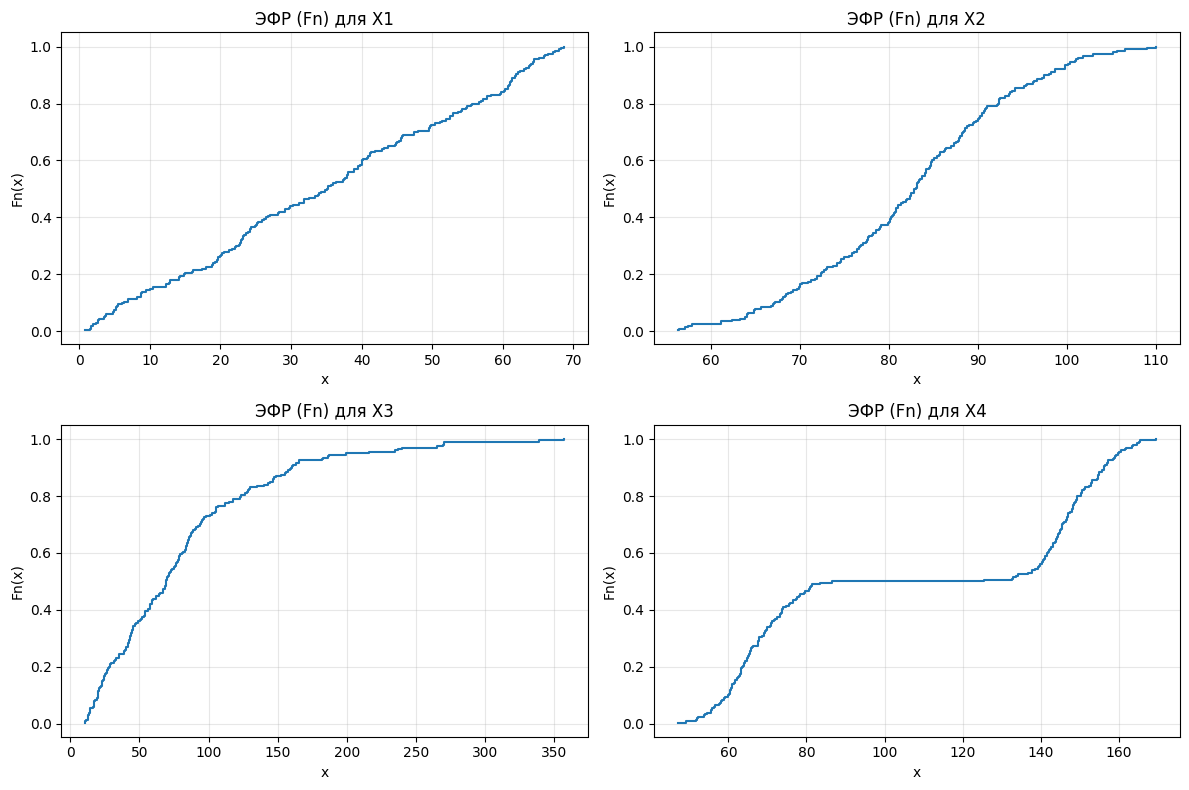

In [ ]:
# 2)
def plot_ecdf(data, column_name):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    plt.step(x, y, where='post')
    plt.title(f'ЭФР (Fn) для {column_name}')
    plt.xlabel('x')
    plt.ylabel('Fn(x)')
    plt.grid(True, alpha=0.3)

plt.figure(figsize=(12, 8))
for i, col in enumerate(df.columns, 1):
    plt.subplot(2, 2, i)
    plot_ecdf(df[col], col)
plt.tight_layout()
plt.show()


3. Обоснование числа интервалов
По правилу Стерджеса (n=200): 8 интервалов


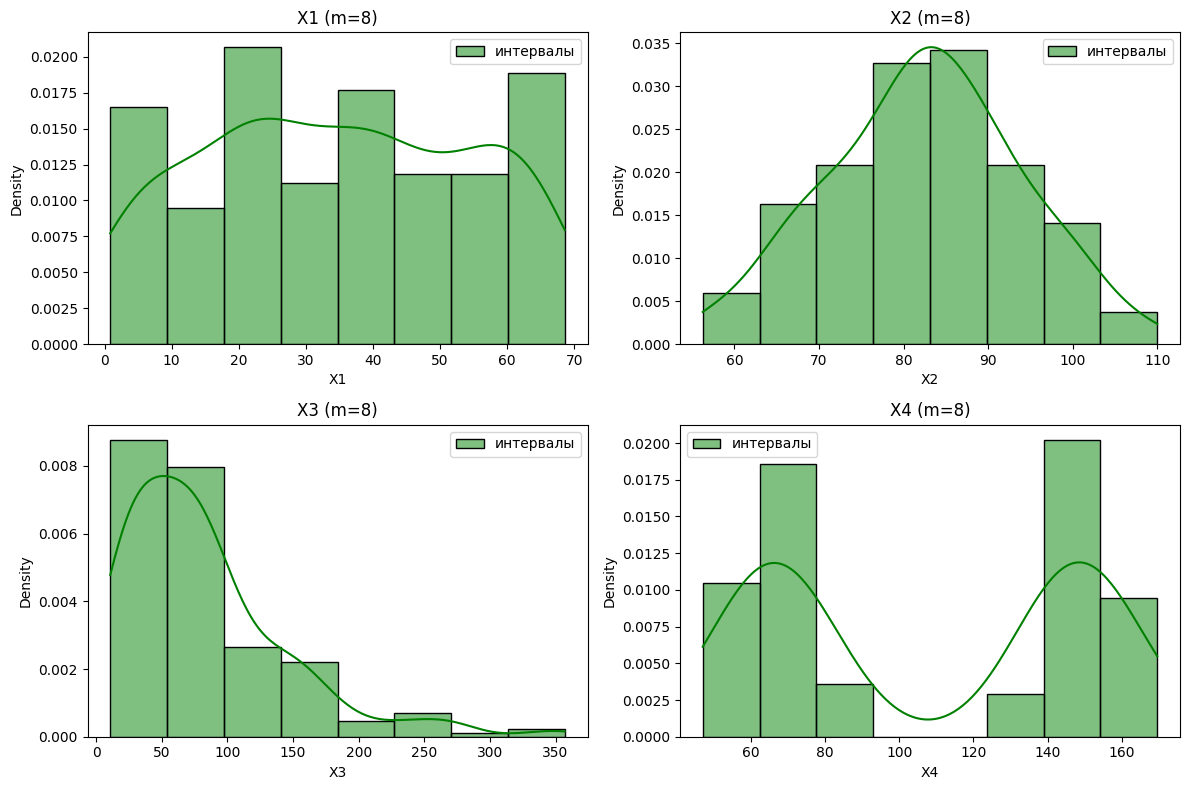

In [ ]:
# 3)
# правило Стерджеса
sturges_m = int(1 + np.log2(n))
# правило Фридмана-Диакониса
def fd_bins(data):
    iqr = stats.iqr(data)
    h = 2 * iqr * (len(data)**(-1/3))
    return int((data.max() - data.min()) / h) if h > 0 else sturges_m

print(f"\n3. Обоснование числа интервалов")
print(f"По правилу Стерджеса (n={n}): {sturges_m} интервалов")

plt.figure(figsize=(12, 8))
for i, col in enumerate(df.columns, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], bins=sturges_m, kde=True, color='green', stat="density", label='интервалы')
    plt.title(f'{col} (m={sturges_m})')
    plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

#4)
def calculate_stats(data):
    x_bar = np.mean(data)
    s2_biased = np.var(data)
    s2_unbiased = np.var(data, ddof=1)
    stats_dict = {
        'среднее': x_bar,
        'дисперсия': s2_biased,
        'несмещенная дисперсия': s2_unbiased,
        'стандартное отклонение': np.sqrt(s2_biased),
        'испр. стандартное отклонение': np.sqrt(s2_unbiased),
        'медиана': np.median(data),
        'Q1 (0.25)': np.percentile(data, 25),
        'Q3 (0.75)': np.percentile(data, 75),
        'асимметрия': stats.skew(data),
        'эксцесс': stats.kurtosis(data)
    }
    return pd.Series(stats_dict)

characteristics = df.apply(calculate_stats)
print(characteristics.round(4))

                                    X1        X2         X3         X4
среднее                        34.7538   82.4484    82.0394   107.6021
дисперсия                     389.8170  128.4957  3917.6641  1761.6822
несмещенная дисперсия         391.7759  129.1414  3937.3509  1770.5349
стандартное отклонение         19.7438   11.3356    62.5912    41.9724
испр. стандартное отклонение   19.7933   11.3640    62.7483    42.0777
медиана                        35.1350   82.9150    69.3550   106.0150
Q1 (0.25)                      19.5650   74.6175    38.9475    65.4650
Q3 (0.75)                      52.5275   90.1550   105.0775   147.9925
асимметрия                      0.0018   -0.0522     1.6052     0.0005
эксцесс                        -1.1735   -0.3861     3.1995    -1.8472


In [ ]:
#5
#X1 симметрично. плотность в целом одинакова на всем отрезке. Выбросов нет, есть четкие границы слева и справа.
#X2 симметрично, среднее и медиана совпадают, выбросов пока нет.
#X3 сильная правая асимметрия, есть левая граница, основная масса данных прижата к левому краю.
#X4 близко к симметричному, выбросов почти нет.

In [ ]:
#4.2
#X1 равномерное: у гистограммы прямоугольная форма без выраженной моды, а коэф. асимметрии и эксцесса близки к нулю. ЭФР возрастает на всем промежутке, среднее и медиана почти совпадают
#X2 нормальное: у гистограммы форма колокола. среднее и медиана почти равны, а коэф. асиметрии близок к нулю
#X3 экспоненциальное со сдвигом: резкий пик у левой границы и убывает к правому краю. среднее значение сильно больше медианы, что подтверждает сильную асиметрию



In [ ]:
#4.3

def calculate_estimates(data, dist_type):
    x_bar = np.mean(data)
    s2_biased = np.var(data)
    s_unbiased = np.std(data, ddof=1)
    x_min = np.min(data)
    x_max = np.max(data)

    if dist_type == 'uniform': # Для X1
        # ММ:
        a_mm = x_bar - np.sqrt(3 * s2_biased)
        b_mm = x_bar + np.sqrt(3 * s2_biased)
        # ММП:
        a_mle, b_mle = x_min, x_max
        return pd.Series({'a_MM': a_mm, 'b_MM': b_mm, 'a_MLE': a_mle, 'b_MLE': b_mle})

    elif dist_type == 'normal': # Для X2

        return pd.Series({'a_MM': x_bar, 'sigma_MM': s_unbiased, 'a_MLE': x_bar, 'sigma_MLE': np.sqrt(s2_biased)})

    elif dist_type == 'expon': # Для X3
        # ММ:
        lambda_mm = 1 / s_unbiased
        c_mm = x_bar - (1 / lambda_mm)
        # ММП:
        c_mle = x_min
        lambda_mle = 1 / (x_bar - c_mle)
        return pd.Series({'c_MM': c_mm, 'lambda_MM': lambda_mm, 'c_MLE': c_mle, 'lambda_MLE': lambda_mle})

results = pd.DataFrame({
    'X1 (Равномерное)': calculate_estimates(df['X1'], 'uniform'),
    'X2 (Нормальное)': calculate_estimates(df['X2'], 'normal'),
    'X3 (Экспоненциальное)': calculate_estimates(df['X3'], 'expon')
})

print(results.round(4))


            X1 (Равномерное)  X2 (Нормальное)  X3 (Экспоненциальное)
a_MLE                 0.8400          82.4484                    NaN
a_MM                  0.5566          82.4484                    NaN
b_MLE                68.6000              NaN                    NaN
b_MM                 68.9510              NaN                    NaN
c_MLE                    NaN              NaN                10.6900
c_MM                     NaN              NaN                19.2910
lambda_MLE               NaN              NaN                 0.0140
lambda_MM                NaN              NaN                 0.0159
sigma_MLE                NaN          11.3356                    NaN
sigma_MM                 NaN          11.3640                    NaN


In [ ]:
#выводы о сравнении:
#для X1: ММ дал более широкий интервал ([0.5566;68.9510]), нежели ММП ([0.84;68.60])
#для X2: оценка среднего (a) полностью совпала (82.4484) в ММП и ММ, а разница в стандартном отклонении маленькая(11.3356 (ММП) и 11.3640 (ММ))
#для X3: есть большое расхождение в параметре смещения с: MMП (10.6900) и ММ (19.2910)

In [ ]:
# 4.4
import scipy.stats as stats
def analyze_probability_4_4(data, dist_type, params_dict, col_name):
    x_bar = data.mean()
    s = data.std()
    x0 = x_bar + s

    #эмпирически
    p_emp = np.sum(data > x0) / len(data)

    #параметрически
    if dist_type == 'uniform':
        # Используем MLE оценки: loc=a, scale=b-a
        a, b = params_dict['a_MLE'], params_dict['b_MLE']
        p_param = stats.uniform.sf(x0, loc=a, scale=b-a)

    elif dist_type == 'normal':
        #MLE оценки: loc=mu, scale=sigma
        mu, sigma = params_dict['a_MLE'], params_dict['sigma_MLE']
        p_param = stats.norm.sf(x0, loc=mu, scale=sigma)

    elif dist_type == 'expon':
        #MLE оценки: loc=c, scale=1/lambda
        c, lam = params_dict['c_MLE'], params_dict['lambda_MLE']
        p_param = stats.expon.sf(x0, loc=c, scale=1/lam)

    return {
        'Столбец': col_name,
        'Порог x0': round(x0, 4),
        'P_эмпирич': round(p_emp, 4),
        'P_параметрич': round(p_param, 4),
        'Расхождение': round(abs(p_emp - p_param), 4)
    }

# данные из результатов 4.3
prob_results = []

prob_results.append(analyze_probability_4_4(df['X1'], 'uniform', results['X1 (Равномерное)'], 'X1 (равномерное)'))
prob_results.append(analyze_probability_4_4(df['X2'], 'normal', results['X2 (Нормальное)'], 'X2 (нормальное)'))
prob_results.append(analyze_probability_4_4(df['X3'], 'expon', results['X3 (Экспоненциальное)'], 'X3 (экспонента)'))

df_prob = pd.DataFrame(prob_results)
print(df_prob.to_string(index=False))

df_prob = pd.DataFrame(prob_results)
print(df_prob.to_string(index=False))

         Столбец  Порог x0  P_эмпирич  P_параметрич  Расхождение
X1 (равномерное)   54.5471       0.22        0.2074       0.0126
 X2 (нормальное)   93.8124       0.16        0.1580       0.0020
 X3 (экспонента)  144.7877       0.15        0.1527       0.0027
         Столбец  Порог x0  P_эмпирич  P_параметрич  Расхождение
X1 (равномерное)   54.5471       0.22        0.2074       0.0126
 X2 (нормальное)   93.8124       0.16        0.1580       0.0020
 X3 (экспонента)  144.7877       0.15        0.1527       0.0027


In [ ]:
 #выводы:
 #наблюдаемые расхождения между двумя способами оценки крайне малы (от 0.002 до 0.0126).
 #это свидетельствует о высоком качестве подбора теоретических моделей для каждой выборки.
 #наименьшее расхождение (0.002) зафиксировано для нормального распределения (X2), что подтверждает его симметричность
 #незначительные отличия обусловлены ограниченным объемом выборки n=200.


In [ ]:
# 4.5 Оценка моментов по сгруппированной выборке
def calculate_grouped_moments(data, col_name):
    n = len(data)
    # правило Стерджеса
    k = int(1 + np.log2(n))

    counts, bin_edges = np.histogram(data, bins=k)

    # середины интервалов
    midpoints = (bin_edges[:-1] + bin_edges[1:]) / 2

    # оценка среднего по сгруппированной выборке
    x_g = np.sum(counts * midpoints) / n

    # оценка дисперсии по сгруппированной выборке
    sigma2_g = np.sum(counts * (midpoints - x_g)**2) / (n - 1)

    # исходные оценки для сравнения
    x_bar = np.mean(data)
    s2_unbiased = np.var(data, ddof=1)

    return {
        'Столбец': col_name,
        'EX (исходн)': round(x_bar, 4),
        'EX (сгрупп)': round(x_g, 4),
        'Отличие EX': round(abs(x_bar - x_g), 4),
        'DX (исходн)': round(s2_unbiased, 4),
        'DX (сгрупп)': round(sigma2_g, 4),
        'Отличие DX': round(abs(s2_unbiased - sigma2_g), 4)
    }

grouped_results = [calculate_grouped_moments(df[col], col) for col in ['X1', 'X2', 'X3']]
print("\n4.5:оценка моментов по сгруппированной выборке")
print(pd.DataFrame(grouped_results).to_string(index=False))


4.5:оценка моментов по сгруппированной выборке
Столбец  EX (исходн)  EX (сгрупп)  Отличие EX  DX (исходн)  DX (сгрупп)  Отличие DX
     X1      34.7538      35.0164      0.2626     391.7759     395.0274      3.2515
     X2      82.4484      82.5588      0.1104     129.1414     127.6587      1.4827
     X3      82.0394      83.8564      1.8171    3937.3509    3737.2066    200.1443


In [ ]:
# 4.6 Доверительные интервалы
def calculate_correct_ci(data, col_name, dist_type):
    n = len(data)
    alpha = 0.05
    x_bar = np.mean(data)
    s_unbiased = np.std(data, ddof=1)
    s2_unbiased = np.var(data, ddof=1)

    res = {'Столбец': col_name}

    # 1. Асимптотический ДИ для EX (для всех столбцов по ЦПТ)
    z_crit = stats.norm.ppf(1 - alpha/2)
    margin_asymp = z_crit * (s_unbiased / np.sqrt(n))
    res['Асимпт. ДИ EX (от)'] = round(x_bar - margin_asymp, 4)
    res['Асимпт. ДИ EX (до)'] = round(x_bar + margin_asymp, 4)

    # 2. Точные ДИ (только для нормального распределения)
    if dist_type == 'normal':
        # Для матожидания (Стьюдент)
        t_crit = stats.t.ppf(1 - alpha/2, n - 1)
        margin_exact = t_crit * (s_unbiased / np.sqrt(n))
        res['Точный ДИ EX (от)'] = round(x_bar - margin_exact, 4)
        res['Точный ДИ EX (до)'] = round(x_bar + margin_exact, 4)

        # Для дисперсии (Хи-квадрат)
        chi2_low = stats.chi2.ppf(1 - alpha/2, n - 1)
        chi2_high = stats.chi2.ppf(alpha/2, n - 1)
        res['Точный ДИ DX (от)'] = round((n - 1) * s2_unbiased / chi2_low, 4)
        res['Точный ДИ DX (до)'] = round((n - 1) * s2_unbiased / chi2_high, 4)
    else:
        res['Точный ДИ EX (от)'] = '-'
        res['Точный ДИ EX (до)'] = '-'
        res['Точный ДИ DX (от)'] = '-'
        res['Точный ДИ DX (до)'] = '-'

    return res

ci_results_correct = [
    calculate_correct_ci(df['X1'], 'X1 (равномерное)', 'uniform'),
    calculate_correct_ci(df['X2'], 'X2 (нормальное)', 'normal'),
    calculate_correct_ci(df['X3'], 'X3 (экспоненциальное)', 'expon')
]

print("\n4.6: доверительные интервалы")
print(pd.DataFrame(ci_results_correct).to_string(index=False))


4.6: доверительные интервалы
              Столбец  Асимпт. ДИ EX (от)  Асимпт. ДИ EX (до) Точный ДИ EX (от) Точный ДИ EX (до) Точный ДИ DX (от) Точный ДИ DX (до)
     X1 (равномерное)             32.0106             37.4970                 -                 -                 -                 -
      X2 (нормальное)             80.8735             84.0233           80.8638            84.033          107.0978          158.8071
X3 (экспоненциальное)             73.3430             90.7357                 -                 -                 -                 -


In [ ]:
# 4.7. итоговый вывод по РГР №1
# 1. Выбор моделей: на основе графического анализа (гистограммы, ЭФР) и численных показателей
# (асимметрия 1.6 для X3, эксцесс -1.17 для X1) определено: X1 — равномерное U(0.84, 68.60);
# X2 — нормальное N(82.45, 11.34^2); X3 — экспоненциальное со сдвигом Exp(lambda, c).

# 2. Оценка параметров: для всех величин ММП признан более эффективным.
# Итоговые модели: X1 ~ U(0.84, 68.60), X2 ~ N(82.45, 11.34^2), X3 ~ Exp(lambda=0.014, c=10.69).
# Для X3 метод моментов дал сильное смещение параметра сдвига (c_MM = 19.29 vs c_MLE = 10.69).

# 3. Адекватность: параметрические оценки вероятностей P(X > x0) практически совпали с
# эмпирическими (макс. расхождение всего 0.0126 у X1). Это подтверждает корректность
# выбора теоретических моделей для описания представленных данных.

# 4. Сгруппированные данные: расчет моментов по интервалам выявил ожидаемую погрешность.
# У X3 зафиксировано макс. отклонение дисперсии (200.14), что связано с высокой
# чувствительностью экспоненциального закона к потере точности при квантовании данных в бины.

# 5. Доверительные интервалы: асимптотические ДИ построены для всех величин, точные —
# только для нормальной (X2). Самый узкий ДИ у X2 (ширина ~3.15), самый широкий у X3
# (ширина ~17.39), что обусловлено разницей в теоретической дисперсии (129.1 vs 3937.3).

# Практический итог: Модели адекватны. Для X2 достигнута максимальная точность оценивания.
# Для X3 (высокая волатильность) для сужения интервалов требуется увеличение объема выборки.
